In [10]:
import pandas as pd
import plotly.express as px

In [11]:
website_sessions = pd.read_csv("data/website_sessions.csv")
orders = pd.read_csv("data/orders.csv")
order_items = pd.read_csv("data/order_items.csv")
order_item_refunds = pd.read_csv("data/order_item_refunds.csv")
website_pageviews = pd.read_csv("data/website_pageviews.csv")
products = pd.read_csv("data/products.csv")


### Identify Sessions at Each Funnel Stage

In this step, website sessions are categorized based on the pages visited during the customer journey. Sessions are filtered for key funnel stages such as landing page, product page, cart, shipping, billing, and order completion. This helps track how users move through the ecommerce funnel and identify where users drop off.

In [12]:
landing_sessions = website_pageviews[
    website_pageviews["pageview_url"].str.contains("home|landing", case=False, na=False)
]["website_session_id"].unique()

product_sessions = website_pageviews[
    website_pageviews["pageview_url"].str.contains("product", case=False, na=False)
]["website_session_id"].unique()

cart_sessions = website_pageviews[
    website_pageviews["pageview_url"].str.contains("cart", case=False, na=False)
]["website_session_id"].unique()

shipping_sessions = website_pageviews[
    website_pageviews["pageview_url"].str.contains("shipping", case=False, na=False)
]["website_session_id"].unique()

billing_sessions = website_pageviews[
    website_pageviews["pageview_url"].str.contains("billing", case=False, na=False)
]["website_session_id"].unique()

thankyou_sessions = website_pageviews[
    website_pageviews["pageview_url"].str.contains("thank", case=False, na=False)
]["website_session_id"].unique()

### Create Funnel Stage Dataset

A structured dataframe is created to summarize the number of sessions at each stage of the customer journey. This dataset will be used to analyze conversion performance and visualize the funnel flow using charts such as Sankey diagrams.

In [13]:
funnel_df = pd.DataFrame({
    "Stage": [
        "Home",
        "Product Page",
        "Cart",
        "Shipping",
        "Billing",
        "Order Complete"
    ],
    "Sessions": [
        len(landing_sessions),
        len(product_sessions),
        len(cart_sessions),
        len(shipping_sessions),
        len(billing_sessions),
        len(thankyou_sessions)
    ]
})

funnel_df

,Stage,Sessions
0,Home,137576
1,Product Page,261231
2,Cart,94953
3,Shipping,64484
4,Billing,52058
5,Order Complete,32313


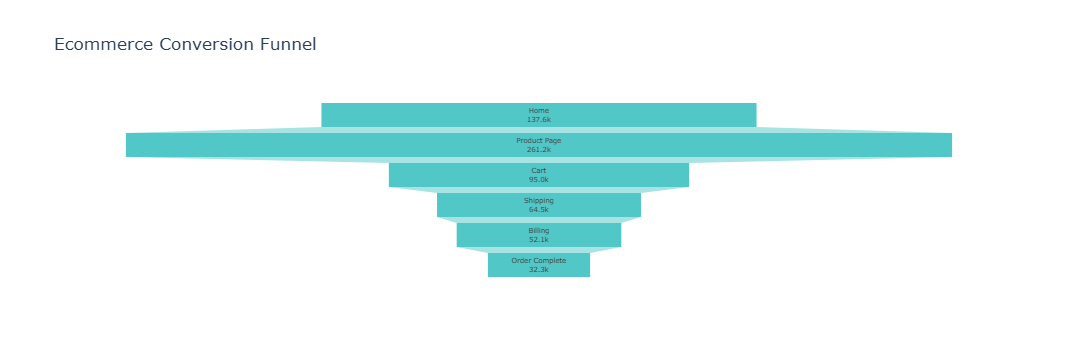

In [32]:
import plotly.express as px

# convert numbers to k format
funnel_df["sessions_k"] = (funnel_df["Sessions"] / 1000).round(1).astype(str) + "k"

# label inside bars
funnel_df["label"] = funnel_df["Stage"] + "<br>" + funnel_df["sessions_k"]

fig = px.funnel(
    funnel_df,
    x="Sessions",
    y="Stage",
    text="label",
    title="Ecommerce Conversion Funnel"
)

fig.update_traces(
    textposition="inside",
    texttemplate="%{text}",
    marker=dict(color="#52C7C7")
)

fig.update_layout(
    xaxis_visible=False,
    yaxis_visible=False,
    plot_bgcolor="white",
    paper_bgcolor="white"
)

fig.show()

In [14]:
funnel_df["Previous_Stage"] = funnel_df["Sessions"].shift(1)
funnel_df["Drop_Off"] = funnel_df["Previous_Stage"] - funnel_df["Sessions"]
funnel_df["Drop_Off_Rate"] = funnel_df["Drop_Off"] / funnel_df["Previous_Stage"]

funnel_df

,Stage,Sessions,Previous_Stage,Drop_Off,Drop_Off_Rate
0,Home,137576,NaN,NaN,NaN
1,Product Page,261231,137576.0,-123655.0,-0.898812
2,Cart,94953,261231.0,166278.0,0.636517
3,Shipping,64484,94953.0,30469.0,0.320885
4,Billing,52058,64484.0,12426.0,0.192699
5,Order Complete,32313,52058.0,19745.0,0.379288


## Drop_off


In [15]:
funnel_df["Previous_Stage"] = funnel_df["Sessions"].shift(1)

In [16]:
funnel_df["Drop_Off"] = (
    funnel_df["Previous_Stage"] - funnel_df["Sessions"]
)

In [17]:
funnel_df["Drop_Off_Rate"] = (
    funnel_df["Drop_Off"] / funnel_df["Previous_Stage"]
)

In [18]:
funnel_df.sort_values("Drop_Off_Rate", ascending=False)

,Stage,Sessions,Previous_Stage,Drop_Off,Drop_Off_Rate
2,Cart,94953,261231.0,166278.0,0.636517
5,Order Complete,32313,52058.0,19745.0,0.379288
3,Shipping,64484,94953.0,30469.0,0.320885
4,Billing,52058,64484.0,12426.0,0.192699
1,Product Page,261231,137576.0,-123655.0,-0.898812
0,Home,137576,NaN,NaN,NaN


In [19]:
session_orders = website_sessions.merge(
    orders,
    on="website_session_id",
    how="left"
)

session_orders.head()

,website_session_id,created_at_x,user_id_x,is_repeat_session,utm_source,utm_campaign,utm_content,device_type,http_referer,order_id,created_at_y,user_id_y,primary_product_id,items_purchased,price_usd,cogs_usd
0,1,19-03-2012 08:04,1,0,gsearch,nonbrand,g_ad_1,mobile,https://www.gsearch.com,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,19-03-2012 08:16,2,0,gsearch,nonbrand,g_ad_1,desktop,https://www.gsearch.com,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,19-03-2012 08:26,3,0,gsearch,nonbrand,g_ad_1,desktop,https://www.gsearch.com,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,19-03-2012 08:37,4,0,gsearch,nonbrand,g_ad_1,desktop,https://www.gsearch.com,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,19-03-2012 09:00,5,0,gsearch,nonbrand,g_ad_1,mobile,https://www.gsearch.com,NaN,NaN,NaN,NaN,NaN,NaN,NaN


 # Device_Type

In [20]:
device_funnel = (
    session_orders.groupby("device_type")["order_id"].nunique() /
    session_orders.groupby("device_type")["website_session_id"].nunique()
)

device_funnel

device_type
desktop    0.085024
mobile     0.030910
dtype: float64

# Sankey_Diagram

In [23]:
flow_landing_product = len(product_sessions)
flow_product_cart = len(cart_sessions)
flow_cart_shipping = len(shipping_sessions)
flow_shipping_billing = len(billing_sessions)
flow_billing_order = len(thankyou_sessions)

drop_landing = len(landing_sessions) - flow_landing_product
drop_product = len(product_sessions) - flow_product_cart
drop_cart = len(cart_sessions) - flow_cart_shipping
drop_shipping = len(shipping_sessions) - flow_shipping_billing
drop_billing = len(billing_sessions) - flow_billing_order

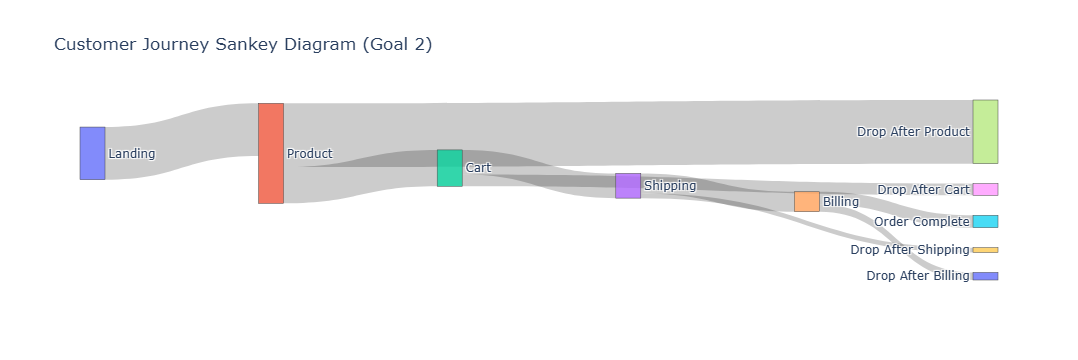

In [24]:
import plotly.graph_objects as go

# Stage values (from your table)
landing = 137576
product = 261231
cart = 94953
shipping = 64484
billing = 52058
order_complete = 32313

labels = [
    "Landing",
    "Product",
    "Cart",
    "Shipping",
    "Billing",
    "Order Complete",
    "Drop After Landing",
    "Drop After Product",
    "Drop After Cart",
    "Drop After Shipping",
    "Drop After Billing"
]

source = [
    0,1,2,3,4,   # Forward flow
    0,1,2,3,4    # Drop flow
]

target = [
    1,2,3,4,5,
    6,7,8,9,10
]

values = [
    min(landing, product),  # Landing → Product
    cart,
    shipping,
    billing,
    order_complete,
    
    landing - min(landing, product),
    product - cart,
    cart - shipping,
    shipping - billing,
    billing - order_complete

]

fig = go.Figure(data=[go.Sankey(
    node=dict(
        pad=20,
        thickness=25,
        label=labels
    ),
    link=dict(
        source=source,
        target=target,
        value=values
    )
)])

fig.update_layout(
    title_text="Customer Journey Sankey Diagram (Goal 2)",
    font_size=12
)

fig.show()

### KPI Calculation



In [22]:
# KPI Calculations for Goal 2

total_page_views = website_pageviews.shape[0]

mobile_sessions = website_sessions[
    website_sessions["device_type"] == "mobile"
]["website_session_id"].nunique()

desktop_sessions = website_sessions[
    website_sessions["device_type"] == "desktop"
]["website_session_id"].nunique()

# Bounce sessions (only 1 pageview)
pageviews_per_session = website_pageviews.groupby(
    "website_session_id"
).size().reset_index(name="pageviews")

bounce_sessions = pageviews_per_session[
    pageviews_per_session["pageviews"] == 1
]["website_session_id"].count()

total_sessions = website_sessions["website_session_id"].nunique()

drop_off_rate = bounce_sessions / total_sessions

# Returning users approximation
returning_sessions = website_sessions[
    website_sessions["is_repeat_session"] == 1
]["website_session_id"].count()

retention_rate = returning_sessions / total_sessions

total_page_views, drop_off_rate, retention_rate, mobile_sessions, desktop_sessions

(1188124,
 np.float64(0.4475639233533035),
 np.float64(0.166119301035589),
 145844,
 327027)

## Insight
In this step, important KPIs related to the customer journey are calculated. 
Total page views measure overall user activity on the website. Bounce sessions are identified to calculate the drop-off rate, which shows how many users leave after viewing only one page. Retention rate is calculated using repeat sessions to understand returning users. Sessions are also segmented by device type (mobile and desktop) to analyze user behavior across different devices.

In [18]:
print(f"Total Page Views: {total_page_views:,}")
print(f"Drop-off Rate: {drop_off_rate:.2%}")
print(f"Retention Rate: {retention_rate:.2%}")
print(f"Mobile Sessions: {mobile_sessions:,}")
print(f"Desktop Sessions: {desktop_sessions:,}")

Total Page Views: 1,188,124
Drop-off Rate: 44.76%
Retention Rate: 16.61%
Mobile Sessions: 145,844
Desktop Sessions: 327,027


In [20]:
website_pageviews.shape

(1188124, 4)

### KPI Dashboard Visualization



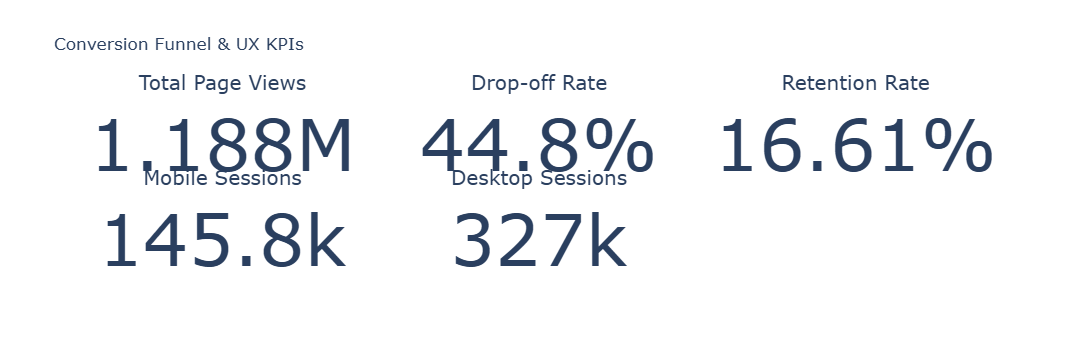

In [22]:
import plotly.graph_objects as go

fig = go.Figure()

fig.add_trace(go.Indicator(
    mode="number",
    value=total_page_views,
    title={"text": "Total Page Views"},
    domain={"row": 0, "column": 0}
))

fig.add_trace(go.Indicator(
    mode="number",
    value=drop_off_rate * 100,
    number={"suffix": "%"},
    title={"text": "Drop-off Rate"},
    domain={"row": 0, "column": 1}
))

fig.add_trace(go.Indicator(
    mode="number",
    value=retention_rate * 100,
    number={"suffix": "%"},
    title={"text": "Retention Rate"},
    domain={"row": 0, "column": 2}
))

fig.add_trace(go.Indicator(
    mode="number",
    value=mobile_sessions,
    title={"text": "Mobile Sessions"},
    domain={"row": 1, "column": 0}
))

fig.add_trace(go.Indicator(
    mode="number",
    value=desktop_sessions,
    title={"text": "Desktop Sessions"},
    domain={"row": 1, "column": 1}
))

fig.update_layout(
    grid={"rows": 2, "columns": 3},
    title="Conversion Funnel & UX KPIs"
)

fig.show()

## Insight

In this step, the KPIs are visualized using Plotly indicator charts. 
The dashboard displays total page views, drop-off rate, retention rate, and device-based sessions. This visualization helps quickly understand user engagement and identify potential areas where user experience improvements can reduce funnel leakage.